In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

In [10]:
lemming_df = pd.read_csv('data/saved/lemming_summary.csv')
lemming_df = lemming_df.set_index(['species_en', 'habitat'])
lemming_df

1995      1996     1997      1998  \
species_en                habitat                                              
Nearctic brown lemming    mesic          200.48   9794.88   200.48   1632.48   
                          wetland        131.95   6974.50  6126.25   6032.00   
Nearctic collared lemming mesic          200.48    744.64   200.48   2634.88   
                          wetland        131.95   1696.50   131.95    471.25   
All                       mesic          400.96  10539.52   400.96   4267.36   
                          wetland        263.90   8671.00  6258.20   6503.25   
                          mesic+wetland  664.86  19210.52  6659.16  10770.61   

                                           1999      2000     2001    2002  \
species_en                habitat                                            
Nearctic brown lemming    mesic          200.48   9393.92   687.36  200.48   
                          wetland        433.55  26898.95  1677.65  131.95   
Nearctic collared lemming mesic          200.48   1603.84   716.00  200.48   
                          wetland        131.95   1112.15  1017.90  301.60   
All                       mesic          400.96  10997.76  1403.36  400.96   
                          wetland        565.50  28011.10  2695.55  433.55   
                          mesic+wetland  966.46  39008.86  4098.91  834.51   

                                           2003       2004  ...      2012  \
species_en                habitat                           ...             
Nearctic brown lemming    mesic          200.48   6100.320  ...   71.6000   
                          wetland        131.95   7315.685  ...  278.0375   
Nearctic collared lemming mesic          200.48   1417.680  ...  146.0640   
                          wetland        131.95     47.125  ...   47.1250   
All                       mesic          400.96   7518.000  ...  217.6640   
                          wetland        263.90   7362.810  ...  325.1625   
                          mesic+wetland  664.86  14880.810  ...  542.8265   

                                            2013        2014        2015  \
species_en                habitat                                          
Nearctic brown lemming    mesic           71.600  14494.7040   8498.9200   
                          wetland         47.125  13098.8650   7001.8325   
Nearctic collared lemming mesic          146.064   1788.5680   1224.3600   
                          wetland         47.125    609.7975    345.8975   
All                       mesic          217.664  16283.2720   9723.2800   
                          wetland         94.250  13708.6625   7347.7300   
                          mesic+wetland  311.914  29991.9345  17071.0100   

                                               2016       2017     2018  \
species_en                habitat                                         
Nearctic brown lemming    mesic           7042.5760   641.5360   71.600   
                          wetland         1037.6925   270.4975   84.825   
Nearctic collared lemming mesic           3439.6640    71.6000   71.600   
                          wetland         1610.7325    93.3075   47.125   
All                       mesic          10482.2400   713.1360  143.200   
                          wetland         2648.4250   363.8050  131.950   
                          mesic+wetland  13130.6650  1076.9410  275.150   

                                             2019       2021      2022  
species_en                habitat                                       
Nearctic brown lemming    mesic          2093.584  44268.848   71.6000  
                          wetland        3187.535  29217.500   78.2275  
Nearctic collared lemming mesic           469.696    469.696  144.6320  
                          wetland         278.980    139.490   47.1250  
All                       mesic          2563.280  44738.544  216.2320  
                          wetland        3466.515  29

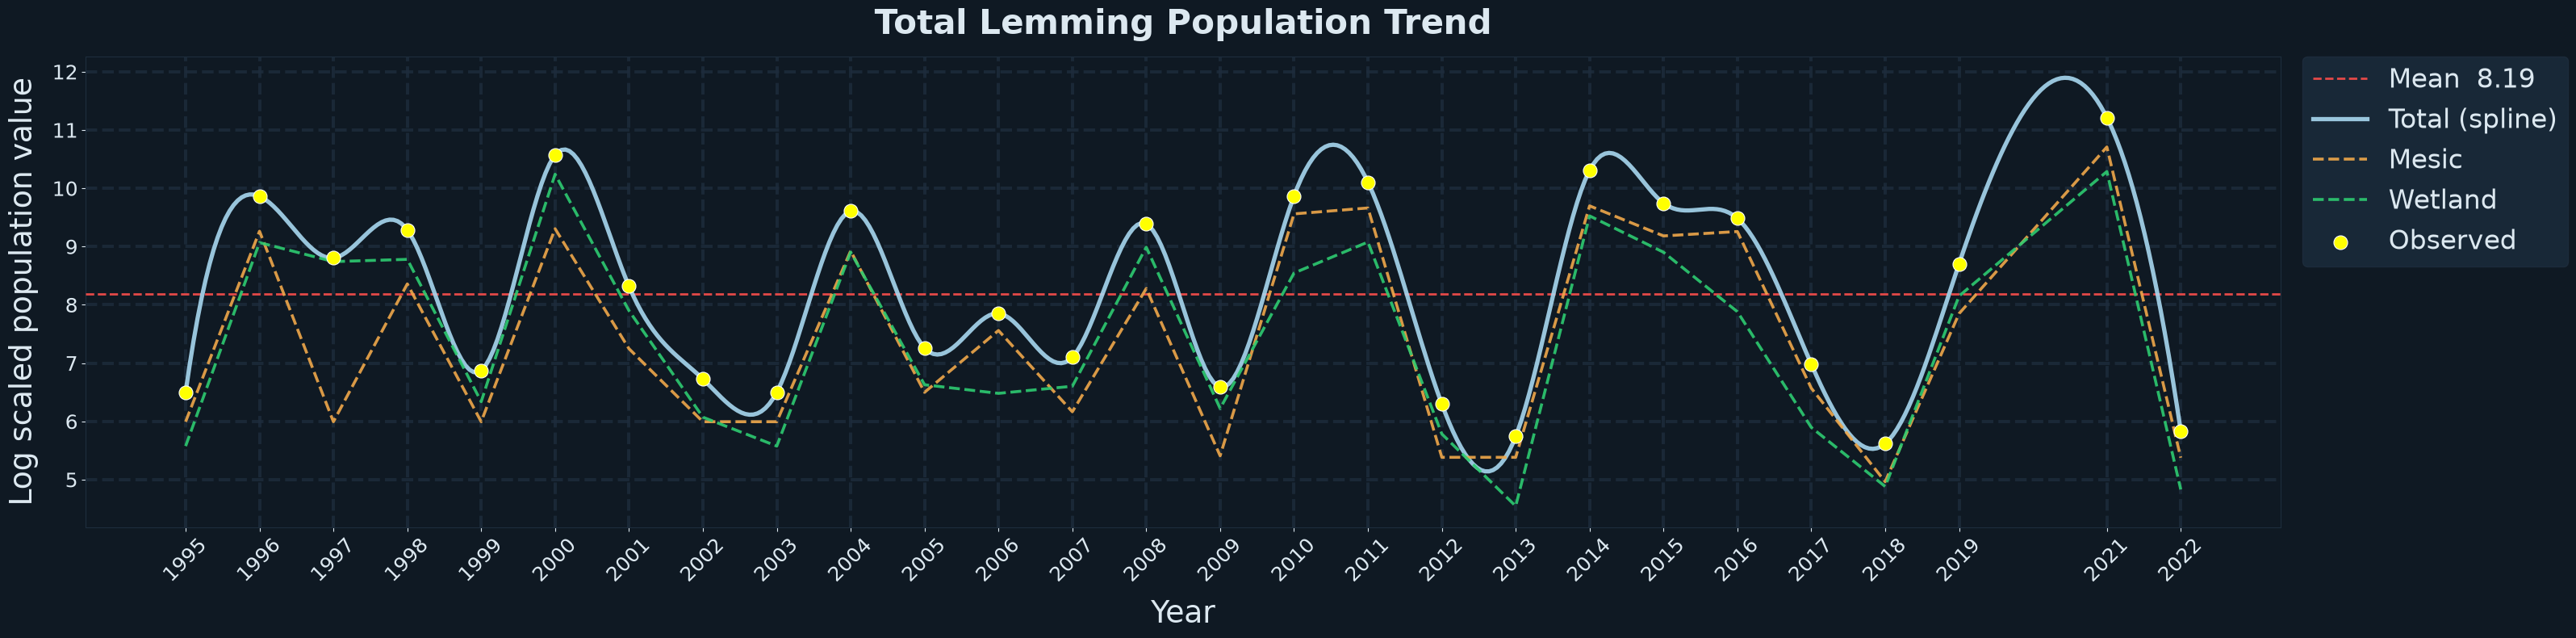

In [19]:
# data: total lemmings (both species, both habitats) per year, log scaled
total_lemmings = lemming_df.loc[("All", "mesic+wetland")]
x = total_lemmings.index.astype(float).values   # years
y = np.log(total_lemmings.values)                # total population estimate, log scaled

# per-habitat totals (both species summed, one habitat at a time), log scaled
mesic_lemmings = np.log(lemming_df.loc[("All", "mesic")].values)
wetland_lemmings = np.log(lemming_df.loc[("All", "wetland")].values)

mean_val = y.mean()
se_val = y.std(ddof=1) / np.sqrt(len(y))

# spline fit
x_fit = np.linspace(x.min(), x.max(), 500)
spline = make_interp_spline(x, y, k=3)
y_fit = spline(x_fit)

# colors
bg_color = '#0f1923'
grid_color = '#1e2d3d'
line_color = '#4a9ede'
spline_color = '#a8d8f0'
mean_color = '#e34948'
se_color = '#2ecc71'
text_color = '#dce8f0'
muted_color = '#6b8fa8'
scatter_color = "yellow"
mesic_color = '#f0a84a'
wetland_color = '#2ecc71'

fig, ax = plt.subplots(figsize=(32, 8))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

ax.grid(True, color=grid_color, linewidth=2.8, linestyle='--', alpha=0.8)
ax.set_axisbelow(True)

ax.axhline(y=mean_val, color=mean_color, linestyle='--', linewidth=2, label=f'Mean  {mean_val:.2f}', zorder=3)

ax.plot(x_fit, y_fit, color=spline_color, linewidth=3.8, alpha=0.9, zorder=4, label='Total (spline)')

# mesic and wetland breakdown, dashed lines, distinct colors
ax.plot(x, mesic_lemmings, color=mesic_color, linestyle='--', linewidth=2.6, alpha=0.9, zorder=4, label='Mesic')
ax.plot(x, wetland_lemmings, color=wetland_color, linestyle='--', linewidth=2.6, alpha=0.9, zorder=4, label='Wetland')

ax.scatter(x, y, color=scatter_color, s=150, zorder=5, edgecolors='white', linewidths=0.8, label='Observed')

ax.set_xlabel('Year', fontsize=27, color=text_color, labelpad=12)
ax.set_ylabel('Log scaled population value', fontsize=27, color=text_color, labelpad=12)
ax.set_title('Total Lemming Population Trend', fontsize=30, color=text_color, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.tick_params(axis='both', colors=text_color, labelsize=18)
plt.xticks(rotation=45)

for spine in ax.spines.values():
    spine.set_edgecolor(grid_color)

legend = ax.legend(fontsize=24, facecolor='#1a2a3a', edgecolor=grid_color,
                   labelcolor=text_color, framealpha=0.9,
                   loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
plt.show()